# Исследование интернет-магазина «Подарочек»

**Цель работы** - оценка деятельности интернет-магазина "Подарочек" за наиболее репрезентативный период времени и разработка рекомендаций по улучшению бизнес-процессов компании.

**Выполнил:** Лазарев Илья

## Оглавление

1.  [Загрузка и предобработка данных](#Шаг-1.-Получение,-осмотр-и-объединение-данных)
    *   [Описание данных](#Описание-данных)
    *   [Обработка пропусков и дубликатов](#Обработка-пропусков-и-дубликатов)
    *   [Изменение типов данных](#Изменение-типов-данных)
    *   [Объединение данных](#Объединение-данных)
2.  [Предобработка данных. Начало анализа](#Шаг-2-Предобработка-и-начало-исследовательского-анализа)
    *   [Проверка аномалий](#Проверка-аномалий-в-данных)
    *   [Удаление аномалий и выбросов](#Удаление-аномалий-и-выбросов)
    *   [Восстановление пропусков](#Восстановление-пропусков)
    *   [Определение периода анализа](#Определение-периода-анализа)  
3.  [Расчет метрик](#Шаг-3.-Расчёт-метрик)
    *   [Цикличность в покупательской активности](#Цикличность-в-покупательской-активности)
    *   [Средняя выручка и уникальные покупатели](#Средняя-выручка-и-уникальные-покупатели)
    *   [Стики-фактор за II-III кв. 2019 года](#Стики-фактор-за-II-III-кв.-2019-года)
    *   [Создание профилей клиентов](#Создание-профилей-клиентов)
    *   [Возвратность клиентов](#Определение-возвратности-клиентов)    
4.  [RFM-сегментация клиентов](#Шаг-4.-Проведение-RFM-сегментации-клиентов)
    *   [Анализ RFM-группы клиентов](#Создание-и-анализ-RFM-группы-клиентов)
5.  [Проверка статистических гипотез](#Шаг-5.-Проверка-статистических-гипотез)
    *   [Сравнение долей возвратных клиентов](#Сравнение-долей-возвратных-и-невозвратных-клиентов)
    *   [Сравнение средних чеков по странам](#Сравнение-средних-чеков-по-странам)    
6.  [Общий вывод](#Шаг-6.-Общий-вывод)
7.  [Дополнительное исследование](#Шаг-7.-Проведение-дополнительного-исследования)

## Шаг 1. Получение, осмотр и объединение данных
1. Загрузим данные из csv-файлов в датафреймы.
2. Изучим общую информацию о датафреймах.
3. Проверим наличие пропусков, примем решение о заполнении.
4. Проверим наличие дубликатов, примем решение об удалении.
5. Рассмотрим типы данных в каждом столбце, приведем типы (если нужно).
6. Проверим соответствие идентификационных номеров.
7. Объединим информацию из всех датафреймов в один.

### Описание данных

In [22]:
# Импортируем:
# базовые библиотеки:
import pandas as pd
import matplotlib.pyplot as plt

# Графики:
import plotly.express as px
import seaborn as sns

# Статистика:
from statsmodels.stats.proportion import proportions_ztest 
from scipy.stats import kruskal  # непараметрический тест Краскела-Уоллеса
from scipy.stats import spearmanr # непараметрический тест Спирмена

# Доп задание №7:
from itertools import combinations # импортируем генератор сочетаний комбинаций из товаров
from collections import Counter # импортируем хэшируемый словарь для пар товаров

In [23]:
# Загрузим данные из csv-файлов в датафреймы:
df_gift = pd.read_csv('https://code.s3.yandex.net/datasets/gift.csv')
df_gift_entry = pd.read_csv('https://code.s3.yandex.net/python-for-analytics/gift_entry.csv', sep=';')

# Узнаем общую информацию, в т.ч. пропуски и дубликаты:
df_gift.info()
print()
df_gift_entry.info()
display(df_gift.sample(2))
display(df_gift_entry.sample(2))  
display(df_gift_entry[df_gift_entry['entry'].isna()]) # Есть 1 пропуск в колонке entry. Можно удалить пустую строку.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356940 entries, 0 to 356939
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   entry_date   356940 non-null  object
 1   order_id     356940 non-null  int64 
 2   customer_id  356940 non-null  int64 
 3   quantity     356940 non-null  int64 
 4   price        356940 non-null  int64 
 5   name_clust   356940 non-null  int64 
 6   entry_id     356940 non-null  int64 
 7   country_id   356940 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 21.8+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   entry_id  2917 non-null   int64 
 1   entry     2916 non-null   object
dtypes: int64(1), object(1)
memory usage: 45.7+ KB


,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id
19143,14/12/2018 12:35,5482,3188,3,495,196,1042,28
321826,22/11/2019 12:07,44604,4475,1,42,235,1756,28


,entry_id,entry
1388,1388,катушка с лентой флора + фауна
243,243,Искусственный цветок фиолетовой анемоны


,entry_id,entry
0,0,NaN


**Вывод**
- пустых значений в `df_gift` нет;
- в `df_gift_entry` есть 1 пустая строка;
- `df_gift` состоит из 356940 строк и 8 колонок, из которых 7 содержат целые числа типа int64, а 1 - object;
- `df_gift_entry` состоит из 2917 строк и 2 колонок, из которых 1 содержит целые числа типа int64, а 1 - object;

### Обработка пропусков и дубликатов

In [24]:
# Удалим пустые значения в df_gift_entry:
df_gift_entry = df_gift_entry[df_gift_entry['entry'].notna()]
print(df_gift_entry.isna().sum())  # Проверим удаление пустой строки.

# Приводим запись entry к единому формату для поиска возможных неявных дубликатов:
df_gift_entry['entry'] = (df_gift_entry['entry']
                          .str
                          .lower()
                          .str.strip()
                          .str.replace(r'\s+', ' ', regex=True))

print(f'\nВсего явных дубликатов в df_gift: {df_gift.duplicated().sum()}')  
print(f'% явных дубликатов в df_gift: {round(100 * df_gift.duplicated().sum() / df_gift.shape[0])}%')
print(f'Всего явных дубликатов в df_gift_entry: {df_gift_entry.duplicated().sum()}')  

# Удаляем явные дубликаты:
df_gift.drop_duplicates(inplace=True)
df_gift_entry.drop_duplicates(inplace=True)

entry_id    0
entry       0
dtype: int64

Всего явных дубликатов в df_gift: 3573
% явных дубликатов в df_gift: 1%
Всего явных дубликатов в df_gift_entry: 0


**Вывод**
- кол-во явных дубликатов в `df_gift` составляет 3573 или 1% от общей величины (дубликаты удалены);
- явные дубликаты в `df_gift_entry` отсутствуют;
- неявные дубликаты в `df_gift` и `df_gift_entry` отсутствуют.

### Изменение типов данных

In [25]:
# Изменим типы данных у датафрейма df_gift:
df_gift['entry_date'] = pd.to_datetime(df_gift['entry_date'], format='%d/%m/%Y %H:%M')

# print(df_gift.max())

# Выбираем все колонки типа 'int' и применяем downcast автоматически
int_cols = df_gift.select_dtypes(include=['integer']).columns

for col in int_cols:
    df_gift[col] = pd.to_numeric(df_gift[col], downcast='integer')

print(f'\n{df_gift.dtypes}')
display(df_gift.sample())


entry_date     datetime64[ns]
order_id                int32
customer_id             int16
quantity                int32
price                   int32
name_clust              int16
entry_id                int16
country_id               int8
dtype: object


,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id
138344,2019-02-06 12:08:00,22016,2348,10,208,415,1136,28


**Вывод**

Приведены типы данных таблицы `df_gift` к нормальному виду (дата - datetime64, целые числа - int с меньшим битом)

### Объединение данных

In [26]:
# Проверим соответствие идентификационных номеров
# Посчитаем разницу между id в разных таблицах, создав множества с уникальными наборами данных
diff = set(df_gift['entry_id']) - set(df_gift_entry['entry_id'])
print(diff) # {0}

# Убираем аномальный entry_id == 0
df_gift = df_gift[df_gift['entry_id'] != 0] # entry_id == 0 отсутствует в словаре товаров, считаем аномалией и исключаем

# Объединим данные таблиц df_gift и df_gift_entry в одну (полные совпадения):
df_merged = df_gift.merge(df_gift_entry, on='entry_id', how='inner')


{0}


**Вывод**

Аномалий в `entry_id` (за исключением `entry_id` = 0) не было. Таблицы `df_gift` и `df_gift_entry` успешно объединены полю `entry_id`.

## Шаг 2. Предобработка и начало исследовательского анализа
1. Найдем выбросы и аномальные значения в столбцах price и quantity, рассчитаем сумму стоимости каждой товарной позиции в датасете, примем и реализуем решение о сохранении или отбрасывании подозрительных данных.
2. Изучим столбцы order_id, customer_id, name_clust, entry_id и country_id.
3. Изучим полноту данных, анализируя время записей. Посчитаем по месяцам количество дней, в которых не было продаж. Выберем период для анализа, содержащий основную часть данных, и далее работаем только с актуальными данными.

### Проверка аномалий в данных

,quantity,price
count,351858.000000,3.518580e+05
mean,10.311174,4.034005e+02
std,146.693425,5.095441e+03
min,-9600.000000,-1.106206e+06
25%,1.000000,1.250000e+02
50%,3.000000,2.080000e+02
75%,10.000000,4.130000e+02
max,80995.000000,1.354133e+06


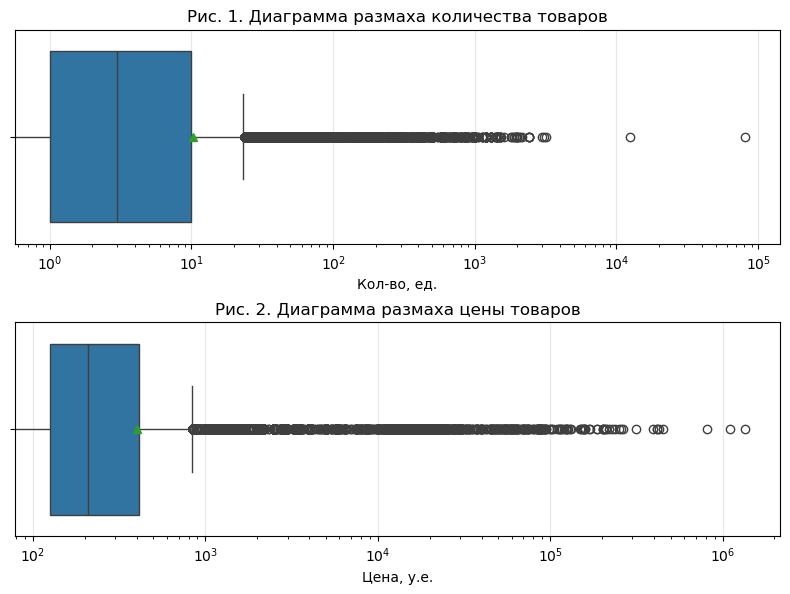

,quantity,price
0.9900,100.0000,1995.0000
0.9950,179.7150,2500.0000
0.9999,1422.8004,126688.2673


,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id,entry
9448,2018-07-12 15:08:00,4298,-1,1,1354133,14,1493,28,комиссия амазон
194535,2019-12-08 14:50:00,29851,-1,1,1106206,0,1548,28,корректировка безнадежный долг
194536,2019-12-08 14:51:00,29852,-1,1,-1106206,0,1548,28,корректировка безнадежный долг
194537,2019-12-08 14:52:00,29853,-1,1,-1106206,0,1548,28,корректировка безнадежный долг
350826,2019-09-12 09:15:00,48149,3554,80995,208,325,2204,28,"поделка из бумаги, маленькая птичка"


In [27]:
# Найдем выбросы и аномальные значения в столбцах price и quantity:
display(df_merged[['quantity','price']].describe())

# Построим графики и изучим данные наглядно:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=False, figsize=(8, 6))  # 2 строки, 1 столбец

# Строим 1 график:
sns.boxplot(x=df_merged['quantity'], ax=ax1, showmeans=True)
ax1.set_title('Рис. 1. Диаграмма размаха количества товаров')
ax1.set_xlabel('Кол-во, ед.')

# Строим 2 график:
sns.boxplot(x=df_merged['price'], ax=ax2, showmeans=True)
ax2.set_title('Рис. 2. Диаграмма размаха цены товаров')
ax2.set_xlabel('Цена, у.е.')

plt.tight_layout() 
for ax in (ax1, ax2):
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xscale('log') 
plt.show()

# Посмотрим, в каких квантилях находятся экстремумы
q = df_merged[['quantity', 'price']].quantile([0.99, 0.995, 0.9999]) 
display(q) # разброс очень большой по сравнению с максимальными значениями

# Выводим таблицу с экстремумами по цене и кол-ву товаров
MAX_QTY = 80_000
MAX_PRICE = 1_000_000
display(df_merged.query('price < 0 or quantity >= @MAX_QTY or price >= @MAX_PRICE'))

**Вывод**
- Графики распределения демонстрируют выраженную асимметрию с длинным "правым хвостом" (положительный скос). В данной ситуации использование стандартного метода межквартильного размаха (IQR) нецелесообразно, так как это приведет к ошибочному отсечению значительной части валидных транзакций. Границы фильтрации определены экспертно на основе анализа графиков "ящик с усами".
- Выявлены единичные транзакции с аномальными чересчур высокими объемами (например, `quantity` = 80 995).
- Обнаружены технические записи с ценой `price` = +/- 1 106 206 у. ед. Анализ показал, что это корректировочные (сторно) операции, где отрицательное значение аннулирует ошибочную положительную запись. При этом одна из сторно-записей задублирована, что требует очистки для исключения искажения итоговой выручки.
- Значительный объем данных (~ 90 тыс. строк) имеет `customer_id` = -1. Данный идентификатор является "плейсхолдером" для анонимных или разовых операций, не привязанных к профилям реальных клиентов. Поскольку одними из задач являются RFM-сегментация и анализ клиентского поведения, данные записи не представляют ценности и подлежат исключению. Однако при подсчете выручки за период мы должны их учесть, поскольку незарегистрированные/неавторизованные покупатели внесли вклад в показатель выручки.

In [28]:

# Булевы маски по видам аномалий по цене и кол-ву товаров
mask_qty_neg = df_merged['quantity'] < 0
mask_qty_pos = df_merged['quantity'] >= MAX_QTY
mask_price_neg = df_merged['price'] < 0
mask_price_zero = df_merged['price'] == 0
mask_price_pos = df_merged['price'] >= 400000
# mask_cust_neg = df_merged['customer_id'] < 0

# Общая маска аномалий
mask_anomaly = (
    mask_qty_neg | mask_qty_pos |
    mask_price_neg | mask_price_zero | mask_price_pos
)

anomaly_values = df_merged[mask_anomaly]

# Счётчики по видам
n_qty_neg = mask_qty_neg.sum()
n_qty_pos = mask_qty_pos.sum()
n_price_neg = mask_price_neg.sum()
n_price_pos = mask_price_pos.sum()
n_price_zero = mask_price_zero.sum()
# n_cust_neg = mask_cust_neg.sum()
n_total = mask_anomaly.sum()

print(f'\nВсего строк с аномалиями и выбросами в df_merged: {n_total}')
print('в том числе:')
print(f'\t- отрицательный выброс price: {n_price_neg}')
print(f'\t- положительный выброс price: {n_price_pos}')
print(f'\t- нулевой price: {n_price_zero}')
print(f'\t- отрицательный выброс quantity: {n_qty_neg}')
print(f'\t- положительный выброс quantity: {n_qty_pos}')
# print(f'\t- отрицательный customer_id: {n_cust_neg}')
print(f'\nДоля аномалий и выбросов: {round(100 * n_total / df_merged.shape[0], 2)}%')

# Табличные данные по типам аномалий
display(
    df_merged[mask_qty_neg]
    .groupby('entry')
    .agg(quantity=('quantity', 'sum'),
         order_id=('order_id', 'nunique'))
    .sort_values(by='quantity')
)
display(
    df_merged[(df_merged['price'] != 0)]
    .groupby('entry')
    .agg(price=('price', 'sum'),
         order_id=('order_id', 'nunique'))
    .sort_values(by='price')
)
display(
    df_merged[mask_price_zero]
    .groupby('entry')
    .agg(order_id=('order_id', 'nunique'))
    .sort_values(by='order_id')
)


Всего строк с аномалиями и выбросами в df_merged: 572
в том числе:
	- отрицательный выброс price: 2
	- положительный выброс price: 7
	- нулевой price: 562
	- отрицательный выброс quantity: 126
	- положительный выброс quantity: 1

Доля аномалий и выбросов: 0.16%


,quantity,order_id
entry,,
пятна от печати/выброшены,-28258,3
"не подлежит продаже, уничтожен.",-15644,9
неправильный ввод акций.,-5760,3
отсутствующий,-4536,9
выброшенный,-4110,9
...,...,...
продан как другой,-25,1
тест,-22,1
образцы,-19,1


,price,order_id
entry,,
корректировка безнадежный долг,-1106206,3
поп-арт нажимает резину,24,2
"блестящий брелок с буквой ""u""",29,1
зеленый поп-арт мао чехол на подушку,38,2
розовая акриловая снежинка из драгоценных камней,38,1
...,...,...
комиссия амазон,1376109,2
подставка для торта regency 3 яруса,2699071,1904
почтовые расходы,3267429,1070


,order_id
entry,
4 традиционных волчка,1
набор из 2 керамических рождественских оленей,1
набор из 9 черных шаров с черепами,1
набор/20 красных бумажных салфеток retrospot,1
найденная коробка,1
...,...
выброшенный,9
"не подлежит продаже, уничтожен.",9
маркет,18


### Удаление аномалий и выбросов

,quantity,price
count,349206.000000,349206.000000
mean,10.318958,318.388092
std,36.049650,449.276242
min,1.000000,6.000000
25%,1.000000,125.000000
50%,3.000000,208.000000
75%,10.000000,413.000000
max,3186.000000,29500.000000


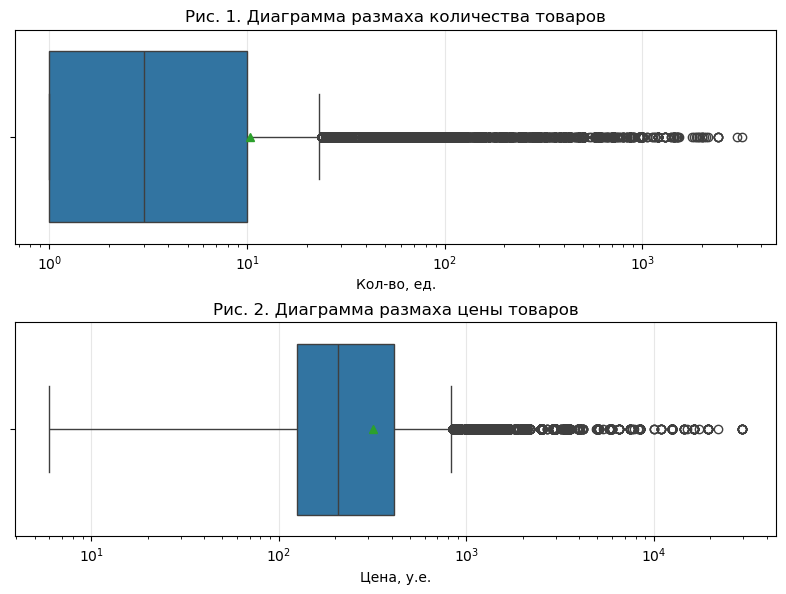

In [29]:
# Очистим df_merged от аномальных значений и выбросов:
df_clean_revenue = df_merged.drop(anomaly_values.index)

# Дополнительно сформируем список из аномальных записей, которые к реальным клиентам никак не относятся:
drop_entry = ['дотком, почтовые расходы','руководство', 'почтовые расходы']

# Удалим строки, содержащие сомнительные записи и не относящиеся к анализу:
df_clean_revenue = df_clean_revenue[~df_clean_revenue['entry'].isin(drop_entry)]



# Выводим результат после удаления:
display(df_clean_revenue[['quantity','price']].describe())

# Посчитаем сумму каждой товарной позиции:
df_clean_revenue['total_revenue'] = df_clean_revenue['price'] * df_clean_revenue['quantity']

# Построим графики и изучим данные наглядно:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=False, figsize=(8, 6))  # 2 строки, 1 столбец

# Строим 1 график после удаления аномалий:
sns.boxplot(x=df_clean_revenue['quantity'], ax=ax1, showmeans=True)
ax1.set_title('Рис. 1. Диаграмма размаха количества товаров')
ax1.set_xlabel('Кол-во, ед.')

# Строим 2 график после удаления аномалий:
sns.boxplot(x=df_clean_revenue['price'], ax=ax2, showmeans=True)
ax2.set_title('Рис. 2. Диаграмма размаха цены товаров')
ax2.set_xlabel('Цена, у.е.')

plt.tight_layout()
for ax in (ax1, ax2):
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xscale('log') 
plt.show()

**Вывод**

- Корректировка сторно-операций: Записи с парными положительными и отрицательными значениями цены (`price`) удалены, поскольку они взаимно погашают друг друга ("схлопываются" в ноль), их наличие создает избыточный шум и искажает расчеты ключевых метрик, а также результаты RFM-анализа.
- Технические списания: Отрицательные значения цены не являются рыночными транзакциями, а представляют собой технические записи (placeholder) для учета убытков. Основной причиной таких списаний является порча товара — в частности, обнаружение типографского брака ("ПЯТНА ОТ ПЕЧАТИ"), на долю которого пришлось 28 258 единиц продукции.
- Аномальные идентификаторы: в выборке сохранены записи с `customer_id` = -1 для дальнейшего расчета общей выручки (в RFM-анализе такие id буду исключены).

### Восстановление пропусков 

In [30]:
# Изучим столбцы order_id, customer_id, name_clust, entry_id и country_id:
display(df_clean_revenue[['order_id', 'customer_id', 'name_clust', 'entry_id', 'country_id']].describe())

# Удалим ненужный для анализа столбец name_clust:
df_clean_revenue = df_clean_revenue.drop(columns=['name_clust'])

# Восстановим пустые значения country_id на основании customer_id:
customers_with_country_0 = df_clean_revenue.query('country_id == 0')['customer_id'].unique()
customers_with_country_not_0 = df_clean_revenue.query('country_id != 0')['customer_id'].unique()

# Находим общие customer_id:
common_customers = set(customers_with_country_0).intersection(customers_with_country_not_0)
print(f"Общие customer_id: {common_customers}")

display(df_clean_revenue.query('customer_id in @common_customers').groupby('customer_id')
                                                                  .agg({'country_id': 'unique'}))

# Создадим словарь с необходимыми данными для замены:
country_map = {7569: 3,
               7578: 25}

# Применим словарь к каждой строке при условии нулевого country_id:
df_clean_revenue['country_id'] = df_clean_revenue.apply(
    lambda row: country_map.get(row['customer_id'], row['country_id']) 
    if row['country_id'] == 0 else row['country_id'],
    axis=1
)
# Создаем переменные для вывода результатов
n_zero_before = (df_clean_revenue['country_id'] == 0).sum()
share_zero_before = round(100 * n_zero_before / df_clean_revenue.shape[0], 2)

# Проверим, что частично восстановлены данные для country_id:
display(f'Кол-во нулевых значений country_id ДО замены: {n_zero_before}')
display(f'Доля нулевых значений country_id ДО замены: {share_zero_before}%')

# Доля нулевых значений с country_id небольшая, но оставим эти данные и заменим их на часто встречающиеся:
df_clean_revenue['country_id'] = df_clean_revenue['country_id'].apply(lambda x: df_clean_revenue['country_id'].mode()[0] if x == 0 else x)
display(f'Кол-во нулевых значений country_id ПОСЛЕ замены: {df_clean_revenue.query("country_id == 0").shape[0]}')

,order_id,customer_id,name_clust,entry_id,country_id
count,349206.000000,349206.000000,349206.000000,349206.000000,349206.000000
mean,26702.660152,3495.466243,473.756044,1525.000126,26.784726
std,13374.945862,2535.854364,255.819788,828.153305,4.913026
min,3031.000000,-1.000000,0.000000,1.000000,0.000000
25%,14854.000000,-1.000000,249.000000,899.000000,28.000000
50%,27392.000000,3640.000000,451.000000,1561.000000,28.000000
75%,38512.000000,5633.000000,706.000000,2223.000000,28.000000
max,48253.000000,7653.000000,929.000000,2916.000000,29.000000


Общие customer_id: {np.int16(7569), np.int16(7578)}


,country_id
customer_id,
7569,"[0, 3]"
7578,"[0, 25]"


'Кол-во нулевых значений country_id ДО замены: 720'

'Доля нулевых значений country_id ДО замены: 0.21%'

'Кол-во нулевых значений country_id ПОСЛЕ замены: 0'

**Вывод**
- Статистические показатели столбцов `order_id`, `customer_id`, `entry_id` находятся в пределах нормы. Cредние и медианные значения близки к друг другу и подтверждает отсутствие грубых аномалий и равномерное распределение записей в структуре заказов.
- `name_clust`: выявлены нулевые (пустые) значения. Учитывая, что данный столбец не несет аналитической ценности для задач проекта, принято решение исключить его из набора данных, чтобы оптимизировать объем используемой памяти.
- `country_id`: обнаружены пропуски в географических данных. Для сохранения целостности выборки проведена процедура восстановления: пустые значения заполнялись на основе исторических данных о местоположении тех же покупателей (по customer_id).
- В ходе проверки удалось восстановить данные для двух клиентов (ID 7569 и 7569), чья страновая принадлежность была однозначно определена по их другим транзакциям.

### Определение периода анализа метрик

2018-01-12 00:00:00 2019-12-10 00:00:00


'Кол-во нулевых значений country_id ДО замены: 0'

'Доля нулевых значений country_id ДО замены: 0%'

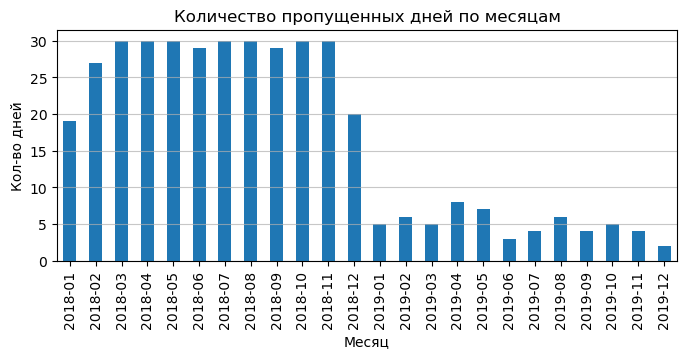

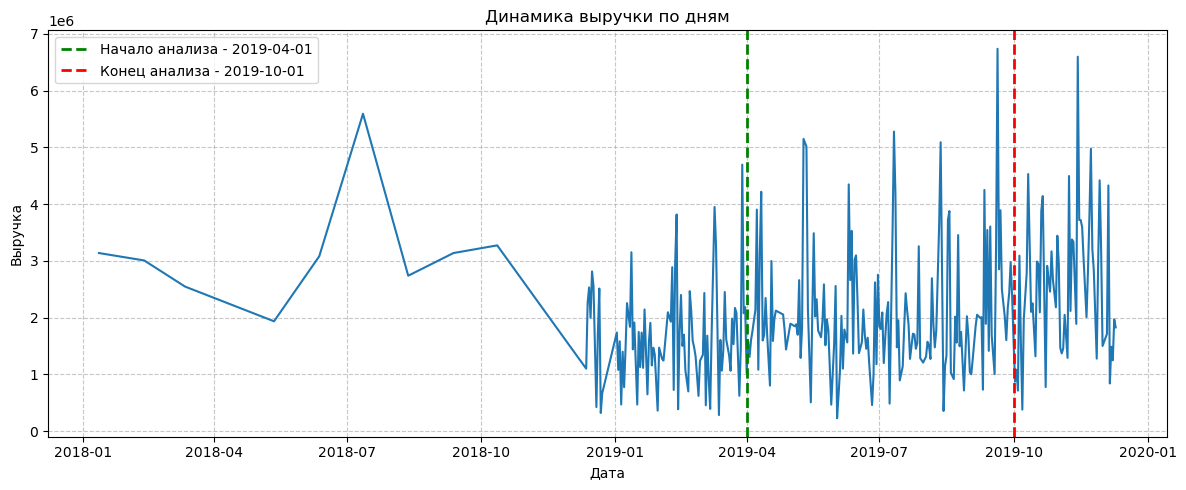

In [31]:
# Изучим полноту данных, проанализируем время записей
# и посчитаем по месяцам количество дней, в которых не было продаж:

# Найдём минимальную и максимальную даты продаж:
sales_start = df_clean_revenue['entry_date'].dt.normalize().min() # 2018-01-12
sales_end = df_clean_revenue['entry_date'].dt.normalize().max() # 2019-12-10
print(sales_start, sales_end)

# Создадим последовательность дат продаж: 
full_range = pd.date_range(start=sales_start, end=sales_end, freq='1D')
sales_dates = df_clean_revenue['entry_date'].dt.normalize().unique()

# Найдем даты, когда отсутствовали продажи:
missing_days = full_range[~full_range.isin(sales_dates)]

# Создадим датафрейм и сгруппируем данные:
missing_df = pd.DataFrame(missing_days, columns=['missing_date'])
missing_by_month = missing_df.groupby(missing_df['missing_date'].dt.to_period('M')).size()

# Строим гистограмму:
plt.figure(figsize=(8, 3))
missing_by_month.plot(kind='bar')
plt.title('Количество пропущенных дней по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Кол-во дней')
plt.grid(axis='y', alpha=0.7)

# Проверим, что частично восстановлены данные для country_id:
display(f'Кол-во нулевых значений country_id ДО замены: {df_clean_revenue.query("country_id == 0").shape[0]}')
display(f'Доля нулевых значений country_id ДО замены: {round(100 * df_clean_revenue.query("country_id == 0").shape[0] 
                                                                                    / df_clean_revenue.shape[0])}%')
daily_revenue = (df_clean_revenue.groupby(df_clean_revenue['entry_date'].dt.normalize())
                 .agg({'total_revenue': 'sum'}).reset_index())

# Строим лийненый график выручки за период:
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_revenue, x='entry_date', y='total_revenue')
# Строим вертикальную линию - начало анализа:
plt.axvline(x=pd.to_datetime('2019-04-01'), color='green', linestyle='--', lw=2, label='Начало анализа - 2019-04-01')
# Строим вертикальную линию - конец анализа:
plt.axvline(x=pd.to_datetime('2019-10-01'), color='red', linestyle='--', lw=2, label='Конец анализа - 2019-10-01')
plt.title('Динамика выручки по дням')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.7)
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Выберем период для выборки данных:
sample_start = pd.to_datetime('2019-04-01')
sample_end = pd.to_datetime('2019-10-01')
df_filtered = df_clean_revenue.query('entry_date >= @sample_start and entry_date < @sample_end').copy()


**Вывод**
- Наибольшие пропуски продаж наблюдаются в 2018 году;
- Далее, начиная с мая по декабрь 2019г., пропуски в продажах стабильно низкие - не более 7 дней в месяц;
- График выручки по дням очень волатилен (много резких пиков и провалов в течение периода);
- **Период анализа метрик установлен на 2–3 квартал 2019 года**, согласно требованиям следующих заданий проекта.

## Шаг 3. Расчёт метрик
1. Оценим по часам и дням недели количество заказов и количество уникальных покупателей. Построим графики и сделаем вывод о наличии цикличности в покупательской активности.
2. Рассчитаем по месяцам среднюю выручку с клиента в день и количество уникальных покупателей. Сделаем вывод о наличии или отсутствии сезонности, если это возможно.
3. Рассчитаем стики-фактор за второй и третий квартал 2019 года.
4. Составим профиль каждого клиента, включим в профиль количество заказов, дату первого и последнего заказа, общую сумму всех заказов, среднюю цену заказа, а также другие показатели по вашему выбору.
5. Разделим клиентов на возвратных и нет по признаку наличия повторных покупок, для каждой из групп на основе профилей клиентов (когда это возможно) рассчитаем средние показатели и оценим их.

### Цикличность в покупательской активности

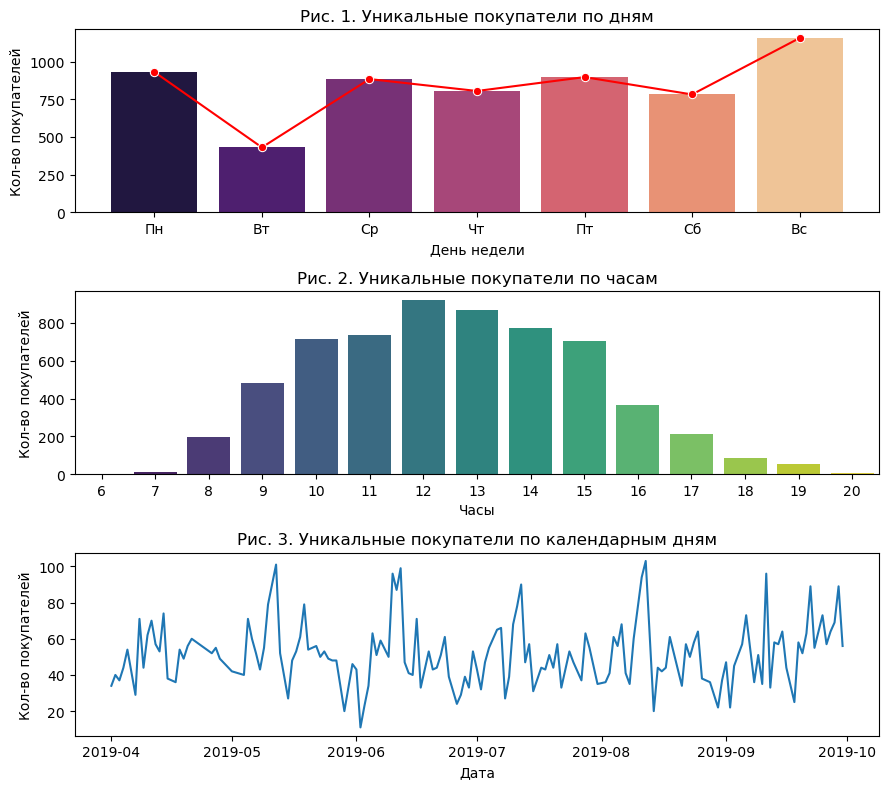

In [32]:
# Уберем customer_id=-1 из анализа цикличности
df_clean = df_filtered.loc[df_filtered['customer_id'] != -1].copy()

# Оценим по часам и дням недели количество заказов и количество уникальных покупателей
# Создадим столбец с днями недели покупки
df_clean['day_of_week'] = df_clean['entry_date'].dt.weekday  # сортируем дни недели по цифрам
# Применим категоризацию
days = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
# Преобразуем значения на всю таблицу
df_clean['day_of_week'] = df_clean['day_of_week'].map(days)
cats = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df_clean['day_of_week'] = pd.Categorical(df_clean['day_of_week'], categories=cats, ordered=True)


# Создадим столбец с часами покупки
df_clean['hour'] = df_clean['entry_date'].dt.hour

# Сгруппируем данные для графиков
orders_by_day = df_clean.groupby('day_of_week', observed=False).agg({'customer_id': 'nunique'}).reset_index()
orders_by_hour = df_clean.groupby('hour').agg({'customer_id': 'nunique'}).reset_index()
orders_by_date = df_clean.groupby(df_clean['entry_date'].dt.date).agg({'customer_id': 'nunique'}).reset_index()

# Построим график кол-ва покупателей по дням недели
fig, (ax1, ax2, ax3) = plt.subplots(3,1, sharex=False, figsize=(9,8))
sns.barplot(data=orders_by_day, x='day_of_week', y='customer_id',ax=ax1, palette='magma', hue='day_of_week', legend=False)
sns.lineplot(data=orders_by_day, x='day_of_week', y='customer_id', ax=ax1, color='red', marker='o', sort=False)
ax1.set_title('Рис. 1. Уникальные покупатели по дням')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Кол-во покупателей')

# Построим график кол-ва покупателей по часам
sns.barplot(data=orders_by_hour, x='hour', y='customer_id',ax=ax2, palette='viridis', hue='hour', legend=False)
ax2.set_title('Рис. 2. Уникальные покупатели по часам')
ax2.set_xlabel('Часы')
ax2.set_ylabel('Кол-во покупателей')

# Построим общий график по дате 
sns.lineplot(data=orders_by_date, x='entry_date', y='customer_id',ax=ax3)
ax3.set_title('Рис. 3. Уникальные покупатели по календарным дням')
ax3.set_xlabel('Дата')
ax3.set_ylabel('Кол-во покупателей')

plt.tight_layout()
plt.show()


**Вывод**
- На рисунке 2 видно, что наибольшее количество уникальных покупателей приходится на пятницу, воскресенье и понедельник. Пиковое значение достигается в воскресенье (более 1200 уникальных покупателей). Получается, что в понедельник покупатели продолжают дооформлять заказы вдобавок к предыдущему дню;
- По вторникам продажи составляли меньше всего за период с апреля по сентябрь 2019 г. (не более 500). Это выглядит необычно;
- На рисунке 2 наблюдается часовая активность покупателей: наибольшая концентрация уникальных покупателей наблюдается в обеденное время — с 12:00 до 13:00. Старт посещений начинается с 7 утра и заканчивается в 8 вечера.

### Средняя выручка и уникальные покупатели

,month,avg_revenue,total_revenue,order_id,customer_id_unique_monthly,avg_check,diff_avg_revenue,diff_customers
0,2019-04,32654.847013,37472181,1212,869,30917.641089,NaN,NaN
1,2019-05,34034.140357,44865422,1439,978,31178.194580,1379.293344,109.0
2,2019-06,33508.061897,44465075,1446,1008,30750.397649,-526.078460,30.0
3,2019-07,32336.969221,44298876,1458,1039,30383.316872,-1171.092676,31.0
4,2019-08,32264.102030,40760444,1339,933,30440.958925,-72.867191,-106.0
5,2019-09,38039.885296,55841501,1588,1157,35164.673174,5775.783266,224.0


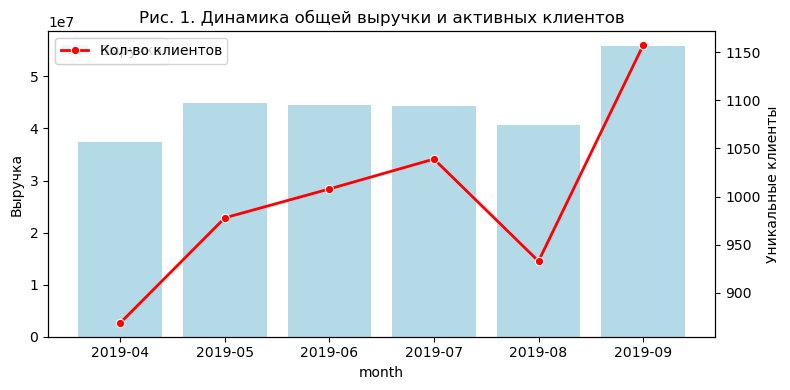

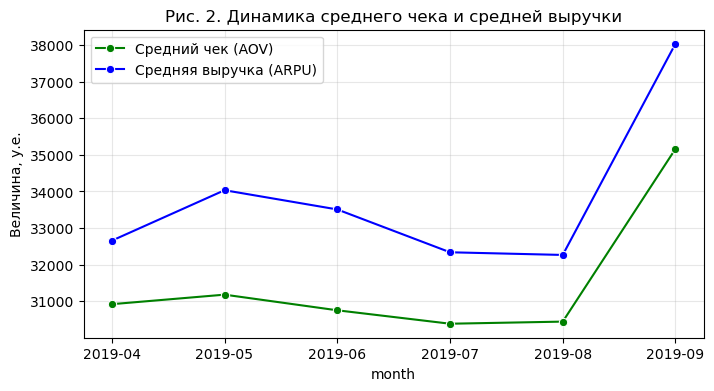

In [33]:
# Создаем столбцы с названием номера месяца
df_clean['date'] = df_clean['entry_date'].dt.date
df_clean['month'] = df_clean['entry_date'].dt.to_period('M')

# Считаем выручку, клиентов и заказы по дням
daily_metrics = df_clean.groupby(['month', 'date']).agg({
    'total_revenue': 'sum',
    'customer_id': 'nunique',
    'order_id': 'nunique'
}).reset_index()

# Выручка на одного клиента в конкретный день
daily_metrics['avg_revenue'] = daily_metrics['total_revenue'] / daily_metrics['customer_id']

# Считаем выручку, клиентов и заказы по месяцам
amr = daily_metrics.groupby('month').agg({
        'avg_revenue': 'mean',   # Средняя выручка с клиента в месяц
        'total_revenue': 'sum',  # Общая выручка за месяц
        'order_id': 'sum'        # Всего заказов за месяц
}).reset_index()  # average monthly revenue

# Считаем уникальных клиентов за месяц
mau = df_clean.groupby('month')['customer_id'].nunique().reset_index(name='customer_id_unique_monthly')
amr = amr.merge(mau, on='month')

# Расчет среднего чека (AOV)
amr['avg_check'] = amr['total_revenue'] / amr['order_id']

# создадим столбцы с изменениями в revenue и customers:
amr['diff_avg_revenue'] = amr['avg_revenue'].diff()
amr['diff_customers'] = amr['customer_id_unique_monthly'].diff()
amr = amr.rename(columns={'price': 'avg_price'})
amr['month'] = amr['month'].astype(str)  # Месяц в строку для графиков

# Выводим таблицу 
display(amr)

# График 1: общая выручка + активные клиенты
fig, ax1 = plt.subplots(figsize=(8, 4))

sns.barplot(data=amr, x='month', y='total_revenue', ax=ax1,
            alpha=0.7, color='skyblue', label='Выручка')
ax1.set_ylabel('Выручка')
plt.title('Рис. 1. Динамика общей выручки и активных клиентов')

ax2 = ax1.twinx()
sns.lineplot(data=amr, x='month', y='customer_id_unique_monthly', ax=ax2,
             color='red', marker='o', linewidth=2, label='Кол-во клиентов')
ax2.set_ylabel('Уникальные клиенты')
plt.legend()
fig.tight_layout()
plt.show()

# График 2: средний чек и средняя выручка
plt.figure(figsize=(8, 4))
sns.lineplot(data=amr, x='month', y='avg_check', marker='o',
             color='green', label='Средний чек (AOV)')
sns.lineplot(data=amr, x='month', y='avg_revenue', marker='o',
             color='blue', label='Средняя выручка (ARPU)')
plt.title('Рис. 2. Динамика среднего чека и средней выручки')
plt.legend()
plt.ylabel('Величина, у.е.')
plt.grid(True, alpha=0.3)
plt.show()

**Вывод**
- На рисунке 1 виден сильный восходящий тренд по кол-ву уникальных покупателей (красная линия) и общей выручке (столбчатая диаграмма) с апреля по июль 2019 г. Так выручка выросла с 37,5 млн. у.е. до 44,3 млн. у.е. (рост на 18% за 3 месяца). В августе наблюдается отрицательная динамика по количеству уникальных покупателей (снижение с 1050 до ~950 чел.), а затем резкий подъем в сентябре до 1150 покупателей. Таким образом, покупателей в августе меньше, но они стали дороже. Причины такой просадки требуют дополнительного анализа (технические сбои или сезонный фактор);
- На рисунке 2 наблюдается рост среднего чека с июля по октябрь 2019 г. за исключением сентября - средний чек за этот месяц снизился с 35,78 тыс. у.е. до 34,99 тыс. у.е. Снижение AOV в ноябре до ~28 тыс. у.е. было самым резким за период. При этом, средняя выручка с покупателя имеет в целом аналогичную тенденцию с AOV: рост с 30 тыс. у.е. до 40 тыс. у.е за июль-октябрь 2019 г. В ноябре ARPU снизился на 23% с ~40 тыс. у.е. до уровня июля 2019 г. ~30 тыс. у.е.;
- В целом, бизнес демонстрирует уверенное масштабирование: за 5 месяцев средний чек вырос более чем на 15%, а общая выручка — почти на 50%. Сентябрьский скачок подтверждает высокую лояльность и готовность аудитории к крупным покупкам. Тем не менее, резкое падение показателей в ноябре требует особого внимания. Это может быть связано как с агрессивными сезонными распродажами («Черная пятница»), которые снизили маржинальность и средний чек, так и с операционными проблемами. Для подтверждения гипотез необходимо сопоставить данные с динамикой цен и проанализировать клиентские отзывы за ноябрь».

### Стики-фактор за II-III кв. 2019 года

In [34]:
# Рассчитаем стики-фактор за второй и третий квартал 2019 года:
start_date = '04-01-2019'
end_date = '09-30-2019'
df_2q3q_2019 = df_clean.query('entry_date >= @start_date and entry_date <= @end_date').copy()
dau = df_2q3q_2019.groupby(df_2q3q_2019['entry_date'].dt.date)['customer_id'].nunique().mean()
mau = df_2q3q_2019.groupby(df_2q3q_2019['entry_date'].dt.month)['customer_id'].nunique().mean()
sticky_factor = 100 * dau / mau
print(f'Стики-фактор за 2 и 3 квартал 2019 года: {sticky_factor:.2f}%') 
# То есть почти 5% пользователей в среднем пользуются сайтом ежедневно

Стики-фактор за 2 и 3 квартал 2019 года: 5.20%


### Создание профилей клиентов

In [35]:
# Составим профиль каждого клиента, включим в профиль количество заказов,
# дату первого и последнего заказа, общую сумму всех заказов, среднюю цену заказа,
# а также другие показатели по выбору:
profiles = df_2q3q_2019.groupby('customer_id').agg({'order_id':'nunique',
                                                        'entry_date': ['min','max'],
                                                        'total_revenue': 'sum',
                                                        'price': 'mean',
                                                        'quantity': 'sum',
                                                        'country_id': 'first',
                                                        'entry': lambda x: x.mode()[0] if not x.mode().empty else None}) \
                                                            .reset_index()

profiles.columns=['customer_id','orders_count','first_date_order','last_date_order', 'total_spent','avg_price',
                  'total_quantity', 'country_id', 'most_frequent_entry']

profiles.sort_values(by='total_spent',ascending=False, inplace=True)
display(profiles.head(5))



,customer_id,orders_count,first_date_order,last_date_order,total_spent,avg_price,total_quantity,country_id,most_frequent_entry
94,1898,39,2019-04-07 10:20:00,2019-09-22 13:53:00,8770218,442.102857,23965,28,визитница кремового цвета в форме сердца
403,2550,19,2019-04-20 11:05:00,2019-09-20 13:38:00,7280018,333.367647,28466,28,нет поющего металлического знака
1812,5354,27,2019-04-28 09:03:00,2019-09-22 11:44:00,7183022,267.976860,49027,16,ланч-бокс для космонавта
2967,7585,10,2019-05-10 12:35:00,2019-08-18 08:51:00,6400109,233.144703,40315,28,"набор из 3 форм для тортов, дизайн кладовой"
377,2489,19,2019-04-05 11:32:00,2019-09-27 11:53:00,4319110,217.641686,30376,28,большая сумка красного цвета retrospot


**Вывод**

Составлен профиль пользователей (показан топ-5 по общим покупкам) за 2-3 кв. 2019 года с указанием кол-ва заказов, первой и последней даты заказа, общей суммы, средней цены и самой частой записи покупки.

### Определение возвратности клиентов

In [36]:
# Разделим клиентов на возвратных и нет по признаку наличия повторных покупок
# Для каждой из групп на основе профилей клиентов (когда это возможно) рассчитаем средние показатели и оценим их:
profiles['returnity'] = profiles['orders_count'] > 1
profiles_grouped = profiles.groupby('returnity').agg({'customer_id': 'count',
                                                      'orders_count': 'mean',
                                                      'total_spent': ['mean','sum'],
                                                      'avg_price': 'mean',
                                                      'total_quantity':'mean',
                                                      'country_id': 
                                                          lambda x: x.mode()[0] if not x.mode().empty else None}) \
                                                            .reset_index()

profiles_grouped.columns = ['returnity', 'customers_count','avg_orders','avg_spent','total_spent',
                            'avg_price', 'avg_quantity', 'frequent_country_id']

# Посчитаем долю продаж среди возвратных и разовых покупателей а также долю самих покупателей:
profiles_grouped['share_revenue_%'] = (profiles_grouped['total_spent'] / profiles_grouped['total_spent'].sum() * 100).round(2)
profiles_grouped['share_customers_%'] = (profiles_grouped['customers_count'] / profiles_grouped['customers_count'] \
                                             .sum() * 100).round(2)
display(profiles_grouped)

,returnity,customers_count,avg_orders,avg_spent,total_spent,avg_price,avg_quantity,frequent_country_id,share_revenue_%,share_customers_%
0,False,1339,1.000000,25310.087379,33890207,343.791318,167.489918,28,12.76,44.65
1,True,1660,4.266265,139564.769277,231677517,302.789455,863.387349,28,87.24,55.35


**Вывод**
- Определен критерий возвратности покупателей в столбце `returnity`. Покупатель, совершивший более 1 покупки за все время считается возвратным;
- Более 55% покупателей совершали более 1 покупки за 2-3 квартал 2019 года;
- Более 55% возвратных покупателей от общего числа клиентов приносили 87% выручки за указанный период;
- Очевидно, что необходимо удержание текущих возвратных покупателей и превращение оставшихся 45% разовых в возвратных;
- Чаще всего заказы оформлялись в стране с `country_id` = 28.

## Шаг 4. Проведение RFM-сегментации клиентов
1. Разделим клиентов на группы по методике RFM;
2. Оценим получившиеся группы, найдем похожие и различающиеся;
3. Сформулируем рекомендации для бизнеса по взаимодействию с сегментами, сопроводив их подходящими графиками и таблицами.

### Создание и анализ RFM-группы клиентов

In [37]:
# Посчитаем кол-во дней с момента совершения последней сделки пользователем:
analysis_date = df_2q3q_2019['entry_date'].max() + pd.Timedelta(days=1)
df_2q3q_2019['order_recency'] = (analysis_date - df_2q3q_2019['entry_date']).dt.days
display(df_2q3q_2019.sample(3))

# Создаем данные для каждого пользователя в разрезе rfm:
rfm = df_2q3q_2019.groupby('customer_id').agg(
    # Количество дней с момента последнего заказа:
    recency = ('order_recency', 'min'),
    # Количество заказов за период времени:
    frequency = ('order_id', 'nunique'),
    # Стоимость всех заказов
    monetary = ('total_revenue', 'sum')
    ).reset_index()
    
display(rfm.head())

# Определим RFM-группы:
display(rfm[['recency', 'frequency', 'monetary']].quantile([0.33, 0.66]))

# Формируем сегменты RFM:
rfm['r'] = pd.qcut(rfm['recency'], q=3, labels=[3,2,1])
rfm['f'] = pd.cut(rfm['frequency'], bins=[0,1,3,float('inf')], labels=[1,2,3])
rfm['m'] = pd.qcut(rfm['monetary'], q=3, labels=[1,2,3])
display(rfm.head())

# Найдем групповой RFM индекс:
rfm[['r','f','m']] = rfm[['r','f','m']].astype('str')
rfm['rfm_group'] = rfm['r'] + rfm['f'] + rfm['m'] 

# Найдем сумму индексов RFM:
rfm[['r','f','m']] = rfm[['r','f','m']].astype('int')
rfm['rfm_sum'] = rfm[['r','f','m']].sum(axis=1)

# Выведем на экран первые строки таблицы:
display(rfm.head(3))

# Сгруппируем данные по сегментам и подсчитаем их размер с сумму индексов:
rfm_group = rfm.groupby('rfm_group').agg({'customer_id':'nunique',
                                          'rfm_sum':'mean'}).reset_index()

# Выведем на экран результат:
display(rfm_group.sort_values(by='customer_id', ascending=False))

,entry_date,order_id,customer_id,quantity,price,entry_id,country_id,entry,total_revenue,day_of_week,hour,date,month,order_recency
125110,2019-05-18 09:23:00,20236,6244,12,42,516,28,открытка на диету с джином и тоником,504,Сб,9,2019-05-18,2019-05,135
94930,2019-07-04 12:35:00,15927,5097,9,85,2736,28,упаковка из 6 флажков с замками из песка в асс...,765,Чт,12,2019-07-04,2019-07,88
248785,2019-06-10 19:49:00,36649,2769,4,495,1868,28,набор из 3 форм для тортов в стиле регентства,1980,Пн,19,2019-06-10,2019-06,111


,customer_id,recency,frequency,monetary
0,1713,131,1,55918
1,1717,78,8,80986
2,1718,145,1,7062
3,1720,89,1,13290
4,1722,3,1,12690


,recency,frequency,monetary
0.33,24.0,1.0,21813.42
0.66,81.0,2.0,57047.12


,customer_id,recency,frequency,monetary,r,f,m
0,1713,131,1,55918,1,1,2
1,1717,78,8,80986,2,3,3
2,1718,145,1,7062,1,1,1
3,1720,89,1,13290,1,1,1
4,1722,3,1,12690,3,1,1


,customer_id,recency,frequency,monetary,r,f,m,rfm_group,rfm_sum
0,1713,131,1,55918,1,1,2,112,4
1,1717,78,8,80986,2,3,3,233,8
2,1718,145,1,7062,1,1,1,111,3


,rfm_group,customer_id,rfm_sum
0,111,453,3.0
25,333,344,9.0
8,211,222,4.0
1,112,220,4.0
12,222,192,6.0
16,233,176,8.0
21,322,167,7.0
13,223,151,7.0
22,323,142,8.0
17,311,135,5.0


In [38]:
# Построим график treemap для визуализации результатов RFM сегментации:
fig = px.treemap(rfm_group, 
                 path=['rfm_group'], # Выбираем RFM-сегменты 
                 values='customer_id', # Устанавливаем размер - количество покупателей
                 color='rfm_sum', # Цвет сегмента будет определять сумма RFM 
                 color_continuous_scale='Sunset',
                 width=1000, 
                 height=600,
                 title='RFM сегментация покупателей интернет-магазина "Подарочек"')

# Отобразим график:
fig.show()

**Вывод**

Рекомендации для бизнеса по взаимодействию с сегментами.

На графике выше выделяются основные группы покупателей: 111, 333, 112, 222, 233, 211 и 223.
- Для групп 111 и 211 можно рекомендовать увеличить частоту покупок и средний чек. В этом помогут скидки за объём покупок и накопительные программы лояльности;
- Группа 333 - это "золотая жила" для компании, покупатели с высокой частотой и суммой покупок. Необходимо предпринять действия по их удержанию: внедрить программы лояльности, индивидуальное обслуживание;
- Группа 112 - доходность на среднем уровне, но покупает давно и нечасто. Стоит применить стратегию реактивации — возвращающие письма, акции, промокоды;
- Группа 222 - стабильные покупатели. Необходимо предпринять действия по удержанию: программы лояльности, индивидуальное обслуживание;
- Группа 233 и 223 - потенциальный выгодный золотой сегмент. Покупают в большом / среднем объеме и высоким чеком, однако не столько активно. Нужно привлекать таких покупателей новыми срочными акциями через уведомления в приложении или через эл. почту и внедрить программы лояльности.

## Шаг 5. Проверка статистических гипотез
1. Сравним доли возвратных и невозвратных клиентов за второй и третий квартал 2019 года при помощи подходящего статистического теста.
2. Сравним средние чеки в странах с `country_id`, равному 3, 6 и 24. На основе статистических тестов сделаем вывод о том, отличаются ли средние чеки в этих странах или нет.
3. Сформулируем собственную гипотезу и проверим её.

### Сравнение долей возвратных и невозвратных клиентов

In [39]:
# Сравним доли возвратных и невозвратных клиентов за второй и третий квартал 2019 года
# при помощи подходящего статистического теста.
# Для сравнения долей 2 независимых выборок подойдет z-тест.

#display(profiles.sample())

q2_profiles = profiles.loc[profiles['first_date_order'].dt.quarter == 2].copy()
q3_profiles = profiles.loc[profiles['first_date_order'].dt.quarter == 3].copy()

# Расчет долей для интерпретации:
retention_q2 = q2_profiles['returnity'].mean()
retention_q3 = q3_profiles['returnity'].mean()

print(f'Доля возвратных клиентов во 2 квартале: {retention_q2:.2%}')
print(f'Доля возвратных клиентов в 3 квартале: {retention_q3:.2%}')

# Записываем данные в нужном формате:
successes = [q2_profiles['returnity'].sum(),
             q3_profiles['returnity'].sum()]

attempts = [len(q2_profiles), len(q3_profiles)]

# Устанавливаем уровень значимости:
alpha = 0.05

# Проводим тест:
z_stat, p_value = proportions_ztest(count=successes, nobs=attempts, alternative='larger')

# Выводим результаты:
print(f"\nz-statistic: {z_stat:.4f}, p-value: {p_value:.4f}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: существует значимая разница между долями.")
else:
    print("Не отвергаем нулевую гипотезу: значимой разницы между долями нет.")

Доля возвратных клиентов во 2 квартале: 68.50%
Доля возвратных клиентов в 3 квартале: 28.50%

z-statistic: 20.7027, p-value: 0.0000
Отвергаем нулевую гипотезу: существует значимая разница между долями.


**Вывод**
- Был выбран правосторонний z-тест, поскольку мы оцениваем доли 2 групп покупателей, совершивших 1 покупку и более во 2 и 3 квартале 2019 года;
- Предварительно рассчитаны доли возврата покупателей во 2 и 3 кв. 2019 года, где с явным отрывом лидирует 2 кв. 2019 (69% против 25%)
- Нам нужно подтвердить гипотезу: 
H1: доля возвратных клиентов во 2 квартале 2019 г. больше, чем доля возвратных клиентов в 3 кв. 2019;
H0: доля возвратных клиентов во 2 квартале 2019 г. меньше или равна доле возвратных клиентов в 3 кв. 2019;
- На имеющихся данных на уровне значимости 5% мы отвергаем нулевую гипотезу. Статистический тест подтверждает альтернативную гипотезу H1: доля возвратных клиентов во 2 квартале 2019 г. значимо превышает долю возвратных клиентов в 3 квартале 2019 г.;
- Следует сказать, что такой колоссальный разрыв между возвратностью может быть обусловлен временем: у покупателей, совершивших первую покупку в 2 кв. 2019 было больше времени совершить последующую покупку, в отличие от группы покупателей 3 квартала того же года.

### Сравнение средних чеков по странам

,country_id,order_id,total_revenue
0,3,10203,5430
1,3,15915,15846
2,3,16950,8562
3,3,17106,12551
4,3,18012,36174
...,...,...,...
275,24,30109,9490
276,24,31205,20286
277,24,33160,288000
278,24,35684,11168


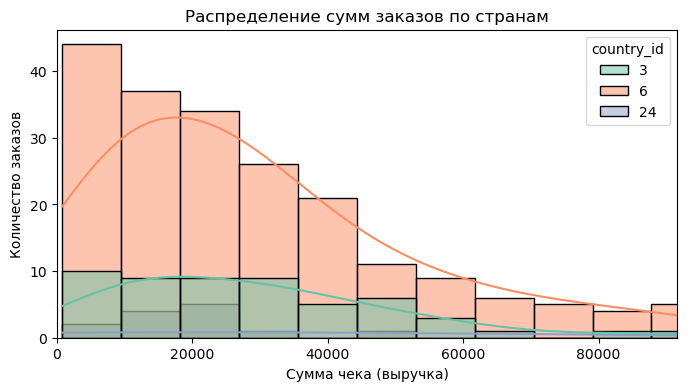

In [40]:
# Сравним средние чеки в странах с country_id, равному 3, 6 и 24. 
# На основе статистических тестов сделаем вывод о том, отличаются ли средние чеки в этих странах или нет.
# Сделаем df по указанным id стран
df_orders_country = df_clean.loc[df_clean['country_id'].isin([3, 6, 24])] \
                    .groupby(['country_id', 'order_id']) \
                    .agg({'total_revenue': 'sum'}).reset_index()
display(df_orders_country)

# Построим график, чтобы понять какое у нас распределение данных:
plt.figure(figsize=(8,4))

# Строим график-гистограмму распределения выручки:
sns.histplot(data=df_orders_country, x='total_revenue', hue='country_id', kde=True, palette='Set2', alpha=0.5)

plt.title('Распределение сумм заказов по странам')
plt.xlabel('Сумма чека (выручка)')
plt.ylabel('Количество заказов')
plt.xlim(0, df_orders_country['total_revenue'].quantile(0.95)) 
plt.show() 

**Вывод**

Данные распределены ненормально - гистограммы вытянуты вправо и удалены неравномерно от медианы. Обычное явление для выручки. Здесь целесообразнее для сравнения медиан нескольких групп использовать не ANOVA-тест, а тест Краскела-Уоллеса.


statistic: 0.0397, p-value: 0.9803
Не отвергаем нулевую гипотезу: значимой разницы между медианами групп стран нет.


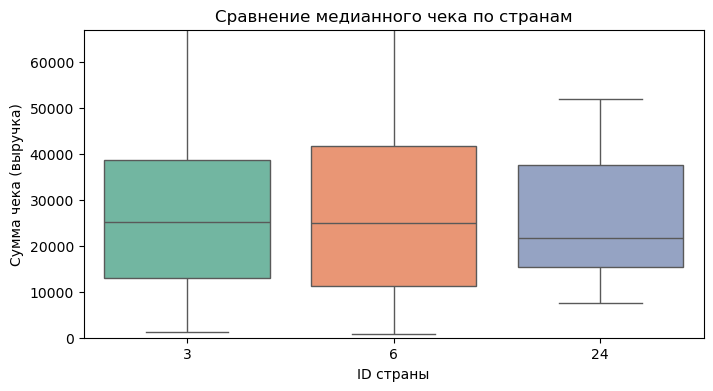

Средний чек по стране 3: 25283.0
Средний чек по стране 6: 25004.0
Средний чек по стране 24: 21653.0


In [41]:
# Отфильтруем данные по суммам чеков каждой страны. Не забываем, что таблица сгруппирована также по order_id:
df_orders_country_3 = df_orders_country.query('country_id == 3')['total_revenue']
df_orders_country_6 = df_orders_country.query('country_id == 6')['total_revenue']
df_orders_country_24 = df_orders_country.query('country_id == 24')['total_revenue']

# Проводим тест:
stat, p_value = kruskal(df_orders_country_3, df_orders_country_6, df_orders_country_24)

# Выводим результаты:
print(f'\nstatistic: {stat:.4f}, p-value: {p_value:.4f}')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: существует значимая разница между медианами групп стран.")
else:
    print("Не отвергаем нулевую гипотезу: значимой разницы между медианами групп стран нет.")
    
plt.figure(figsize=(8, 4))

# Построим ящик с усами:
sns.boxplot(
    x='country_id', 
    y='total_revenue', 
    data=df_orders_country,
    hue='country_id',
    palette='Set2',
    legend=False
)

plt.title('Сравнение медианного чека по странам')
plt.xlabel('ID страны')
plt.ylabel('Сумма чека (выручка)')

# Ограничим y, чтобы убрать выбросы:
plt.ylim(0, df_orders_country['total_revenue'].quantile(0.90)) 
plt.show()

print(f'Средний чек по стране 3: {df_orders_country_3.median()}')
print(f'Средний чек по стране 6: {df_orders_country_6.median()}')
print(f'Средний чек по стране 24: {df_orders_country_24.median()}')

График "ящик с усами" это показал наглядно. Действительно, медиана среднего чека по странам № 3, 6 и 24 примерно на одном уровне 23 000-24 000 у.е.

In [42]:
# Сформулируем собственную гипотезу и проверим её:
# H1: Чем больше цена товара, тем меньше его покупают
# H0: Цена товара не влияет на объем покупок или влияет в большую сторону
df_grouped = df_clean.groupby('entry_id').agg({'price': 'mean',
                                             'quantity': 'sum'}).reset_index()
prices = df_grouped['price']
purchases = df_grouped['quantity']

# Проводим тест Спирмена:
corr, p_value = spearmanr(prices, purchases, alternative='less')

# Выводим результаты:
print(f'\ncorr: {corr:.4f}, p-value: {p_value:.4f}')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: С ростом цены объем купленных товаров уменьшается.")
else:
    print("Не отвергаем нулевую гипотезу: цена не влияет на объем покупок или влияет в большую сторону.")


corr: -0.3706, p-value: 0.0000
Отвергаем нулевую гипотезу: С ростом цены объем купленных товаров уменьшается.


**Вывод**

Гипотеза H0 отклонена. Цена и количество купленных товаров находятся в обратной пропорции (работает закон спроса). Это подтверждает и коэффициент корреляции -0.3749

## Шаг 6. Общий вывод
Опишем полученные результаты и зафиксируем итоговый вывод проведённого исследования.

**Общие результаты**

Целью данного проекта являлась оценка деятельности интернет-магазина "Подарочек" за наиболее репрезентативный период времени и разработка рекомендаций по улучшению бизнес-процессов компании.
Для этого были выгружены исходные данные за декабрь 2018-декабрь 2019 гг. с информацией о продажах конкретных товаров покупателями.

Для качественного и репрезентативного анализа проведена обработка данных:
1. удалены дубликаты (1% от общего числа или 3579 строк);
2. удалены аномалии и выбросы (26% или 91496 строк);
3. восстановлены пропуски в колонке `country_id` (720 строк восстановлено);
4. изменены типы данных столбцов для ускорения работы (применены такие типы как: `datetime64`, `int16`, `int32`);
5. (!) выбран период для анализа с апреля 2019 г. по сентябрь 2019 г.(*)

Результаты проведенного исследования показали:
1. Наибольшее количество уникальных покупателей приходится на период с пятницы по воскресенье. Пиковое значение достигается в воскресенье (более 1200 уникальных покупателей в этот день);
2. По вторникам продажи полностью отсутствовали за декабрь 2018-декабрь 2019 гг. Вероятно, вторник - выходной день у пункта выдачи заказов;
3. Наблюдается пик часовой активности новых покупателей в обеденное время — с 12:00 до 13:00. Старт посещения начинается в 7 утра и заканчивается в 8 вечера;
4. График выручки по дням очень волатилен (много резких пиков и провалов в течение периода);
5. Общая выручка интернет-магазина непрерывно выросла с июля по ноябрь 2019 г. почти на 100% - с 35,6 млн. у.е. до 70,3 млн. у.е.  В то же время увеличилось и число уникальных пользователей с августа по ноябрь с менее чем 1000 до 1600 чел. и более в месяц, что является хорошим сигналом масштабирования бизнеса;
6. Вырос средний чек (AOV) и средняя выручка (ARPU) с июля по октябрь 2019 г. В то же время снижение данных показателей в ноябре было самым резким за период: ARPU снизился на 23% с ~40 тыс. у.е. до уровня июля 2019 г. ~30 тыс. у.е., AOV снизился на 
7. Стики-фактор за 2-3 квартал 2019 года составил почти 5%, что говорит о том, что только 5% покупателей делают заказы ежедневно;
8. Почти 55% покупателей совершали более 1 покупки за 2-3 квартал 2019 года. Одновременно, возвратные покупатели принесли интернет-магазину 86% выручки за этот период. Кроме того, больше всего заказов оформлялось в стране с `country_id` = 28;
9. Проведена RFM-сегментация. Самые многочисленные группы клиентов - 111, 333, 112, 222;
10. Был выбран односторонний z-тест в отношении групп клиентов, поскольку мы оцениваем доли 2 группы покупателей, совершивших 1 покупку и более 1 покупки во 2-3 квартале 2019 года;
11. Статистический z-тест подтвердил альтернативную гипотезу H1: доля возвратных клиентов во 2 квартале 2019 г. значимо превышает долю возвратных клиентов в 3 квартале 2019 г. Такой колоссальный разрыв между возвратностью может быть обусловлен временем: у покупателей, совершивших первую покупку в 2 кв. 2019 было больше времени совершить последующую покупку, в отличие от группы покупателей 3 квартала;
12. Медиана среднего чека по странам № 3, 6 и 24  за 2-3 кв. 2019 г. примерно одинаковая и на одном уровне 23 000-24 000 у.е. это подтверждено графически и статистически;
13. Цена и количество купленных товаров находятся в обратной пропорции (работает закон спроса: чем выше цена, тем ниже спрос на товар). Это подтверждает и коэффициент корреляции -0.3749 (умеренный), полученный при тестировании через модель Спирмена;
14. Самые частые товары, которые покупают вместе - это товары из категории сумок, например: `"большая сумка розового цвета в горошек"` и `"большая сумка красного цвета retrospot"` (540 раз).

Рекомендации:
1. Рассмотреть возможность переноса всех внутренних операций / расходов из таблицы `df_gift`: от списания брака до продажи товаров руководству в отдельный датасет. Из-за смешивания данных между продажей товаров реальным покупателям и внутренними проводками, пришлось удалить 26% аномалий и выбросов - расходных операций;
2. Провести качественные оценки товара (сервиса) по системе обратной связи от клиентов за ноябрь 2019 года. Дополнительно необходимо получить экспертную оценку от службы качества в связи со снижением среднего чека за тот же месяц;
3. Удерживать 55% возвратных покупателей и стимулировать оставшиеся 45% разовых клиентов делать дополнительные покупки;
4. Рассмотреть возможность установить ежедневную выдачу товаров без выходных посменно, чтобы охватить вторник.
5. В отношении RFM-групп клиентов:
- Для групп 111 и 211 можно рекомендовать увеличить частоту покупок и средний чек. В этом помогут скидки за объём покупок и накопительные программы лояльности;
- Группа 333 - это "золотая жила" для компании, покупатели с высокой частотой и суммой покупок. Необходимо предпринять действия по их удержанию: внедрить программы лояльности, индивидуальное обслуживание;
- Группа 112 - доходность на среднем уровне, но покупает давно и нечасто. Стоит применить стратегию реактивации — возвращающие письма, акции, промокоды;
- Группа 222 - стабильные покупатели. Необходимо предпринять действия по удержанию: программы лояльности, индивидуальное обслуживание;
- Группа 233 и 223 - потенциальный выгодный золотой сегмент. Покупают в большом / среднем объеме и высоким чеком, однако не столько активно. Нужно привлекать таких покупателей новыми срочными акциями через уведомления в приложении или через эл. почту и внедрить программы лояльности.
6. Ввести акции на дополняющие товары более высокого ценового сегмента (не сумки), например заказ через интернет мебели и доп. скидка на услуги перевозки.

*В пункте 3 шага 2 сказано выбрать период самостоятельно и далее работать только с актуальными данными. Я выбрал период с июня по ноябрь 2019 г., поскольку в этот промежуток была повышенная покупательская активность, выполняется условие актуальности, а также присутствует меньшее кол-во пропусков в данных. При этом, на шагах 3-5 просят оценивать метрики за период с апреля по сентябрь 2019 года. Чтобы не противоречить заданию, итоговый период  рассмотрения установлен с апреля по сентябрь 2019 г.

## Шаг 7. Проведение дополнительного исследования (дополнительное задание) 
Исследуем, какие товары чаще всего покупают вместе (за период анализа).

In [49]:
# Создаем словарь для добавления уникальных пар
pairs = Counter()

# Берём только нужные колонки
df_pairs = df_clean[['order_id', 'entry', 'quantity']].copy()

# Отбрасываем позиции с нулевым/отрицательным количеством
df_pairs = df_pairs[df_pairs['quantity'] > 0]

# display(df_pairs.head())

for order_id, group in df_pairs.groupby('order_id'):
    items = group['entry'].unique()
    if len(items) < 2:
        continue
    # считаем все пары товаров внутри заказа
    for a, b in combinations(sorted(items), 2):
        pairs[(a, b)] += 1

# Преобразуем в датафрейм и берём топ-10
df_result = (pd.Series(pairs)
             .sort_values(ascending=False)
             .head(10)
             .reset_index())
df_result.columns = ['Товар 1', 'Товар 2', 'Встречаемость']
display(df_result)

,Товар 1,Товар 2,Встречаемость
0,большая сумка красного цвета retrospot,большая сумка розового цвета в горошек,312
1,сумка для обеда в розовый горошек,сумка для обеда красная retrospot,287
2,праздничная овсянка,пятнистая овсянка в рамке,286
3,сумка для обеда дизайн суки,сумка для обеда красная retrospot,277
4,сумка для обеда дизайн суки,сумка для обеда машинки синяя,262
5,сумка для обеда красная retrospot,сумка для обеда с дизайном яблока,261
6,зеленая чашка и блюдце в стиле регентства,"розы регентства, чашка и блюдце",259
7,сумка для обеда в розовый горошек,сумка для обеда машинки синяя,256
8,сумка для обеда красная retrospot,"сумка для обеда, дизайн космического мальчика",255
9,большая сумка красного цвета retrospot,сумка для обеда красная retrospot,254


**Вывод**

Чаще всего покупают вместе товары в виде сумок, например, `"большая сумка розового цвета в горошек"` и `"сумка для обеда красная retrospot"` - 312 и 287 раз.

In [50]:
# Для понимания, какие товары в магазине самые дорогие
display(df_clean.query('price > 1000').groupby(['entry','price']).agg({
                                                              'order_id': 'nunique'}) \
                                        .sort_values(by=['price','order_id'],ascending=False))

order_id
entry                                              price          
винтажный красный кухонный шкаф                    29500         2
старинный синий кухонный шкаф                      29500         1
двойное кресло античный белый металл               19500         8
буфет с семнадцатью ящиками в деревенском стиле    16500         5
                                                   14500         4
...                                                            ...
кухонный органайзер из проволоки цвета слоновой... 1040         25
табурет «дом, милый дом»                           1040          7
кухонный органайзер из цинковой проволоки          1040          3
подвесной светильник для кафе цвета слоновой кости 1040          1
старинная рождественская скатерть                  1039          1

[183 rows x 1 columns]

Одни из самых дорогих товаров в магазине - это мебель и предметы интерьера.